In [30]:
import  pandas as pd

In [31]:
kp_df = pd.read_csv("kyphosis.csv")
kp_df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [32]:
kp_df["Age"] = kp_df["Age"] / 12



In [33]:
kp_df

,Kyphosis,Age,Number,Start
0,absent,5.916667,3,5
1,absent,13.166667,3,14
2,present,10.666667,4,5
3,absent,0.166667,5,1
4,absent,0.083333,4,15
...,...,...,...,...
76,present,13.083333,3,13
77,absent,2.166667,7,13
78,absent,10.000000,2,13
79,present,3.500000,7,6


disini agar hasil bisa tidak desimal, kita membulatkan hasil sebelumnya ke angka terdekat dan mengubah tipe data menjadi int

In [34]:
kp_df["Age"] = kp_df["Age"].round().astype(int)


In [35]:
kp_df

,Kyphosis,Age,Number,Start
0,absent,6,3,5
1,absent,13,3,14
2,present,11,4,5
3,absent,0,5,1
4,absent,0,4,15
...,...,...,...,...
76,present,13,3,13
77,absent,2,7,13
78,absent,10,2,13
79,present,4,7,6


atau juga bisa langsung seperti dibawah ini, habis melakukan operasi langsung mengubah hasil menjadi round dan cast ke int

In [36]:
#kp_df['Age'] = (kp_df['Age'] / 12).round().astype(int)

In [37]:
kp_df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,7.000000,4.049383,11.493827
std,4.868265,1.619423,4.883962
min,0.000000,2.000000,1.000000
25%,2.000000,3.000000,9.000000
50%,7.000000,4.000000,13.000000
75%,11.000000,5.000000,16.000000
max,17.000000,10.000000,18.000000


<Axes: >

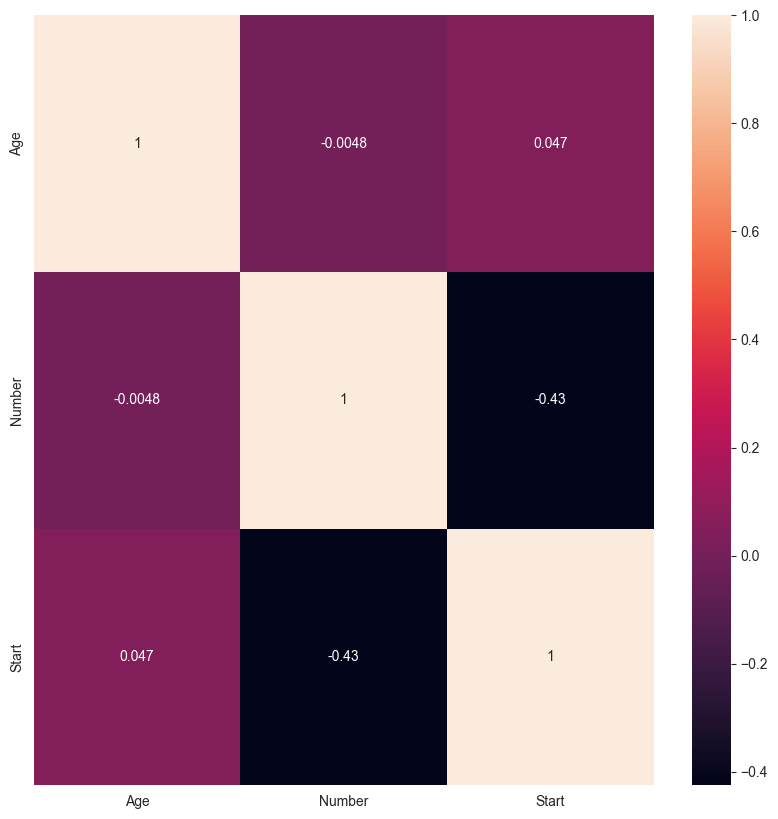

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
korelasi = kp_df.corr(numeric_only=True)
f ,ax = plt.subplots(figsize=(10,10))
sns.heatmap(korelasi, annot=True)

disini akan menggunakan metode ke 2

In [46]:
kp_df2= pd.read_csv("kyphosis.csv")

In [47]:
kp_df2["Age"]=kp_df2["Age"].astype(float)

In [41]:
kp_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Kyphosis  81 non-null     object 
 1   Age       81 non-null     float64
 2   Number    81 non-null     int64  
 3   Start     81 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 2.7+ KB


ini cara menampilkan siapa saja yang umurnya sama dengan batas minimal dan maximal

In [74]:
kp_df2[ kp_df2["Age"] == kp_df2["Age"].max()]

,Kyphosis,Age,Number,Start,Age_in_year
73,absent,1.0,4,10,17.166667


In [75]:
kp_df2[ kp_df2["Age"] == kp_df2["Age"].min()]


,Kyphosis,Age,Number,Start,Age_in_year
4,absent,0.0,4,15,0.083333
5,absent,0.0,2,16,0.083333
13,absent,0.0,4,12,0.083333
15,absent,0.0,3,16,0.083333
36,absent,0.0,3,9,0.083333


In [48]:
def ubah_usia(x):
    return x / 12

In [53]:
kp_df2["Age_in_year"]=kp_df2["Age"].apply(ubah_usia)

In [54]:
kp_df2

,Kyphosis,Age,Number,Start,Age_in_year
0,absent,71.0,3,5,5.916667
1,absent,158.0,3,14,13.166667
2,present,128.0,4,5,10.666667
3,absent,2.0,5,1,0.166667
4,absent,1.0,4,15,0.083333
...,...,...,...,...,...
76,present,157.0,3,13,13.083333
77,absent,26.0,7,13,2.166667
78,absent,120.0,2,13,10.000000
79,present,42.0,7,6,3.500000


hati-hati ketika menulis Minmaxscaler karena minmaxscaler jika m nya kecil adalah

fit transform harus menerima data array, makanya menggunakan values agar bisa mengembalikan nilai array

ini adalah normalisasi

In [64]:
kp_df3=pd.read_csv("kyphosis.csv")

In [65]:
from sklearn.preprocessing import MinMaxScaler
normal_scale = MinMaxScaler()
kp_df3["Age"]=normal_scale.fit_transform(kp_df3["Age"].values.reshape(-1,1))


In [66]:
kp_df3.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,0.403192,4.049383,11.493827
std,0.283435,1.619423,4.883962
min,0.000000,2.000000,1.000000
25%,0.121951,3.000000,9.000000
50%,0.419512,4.000000,13.000000
75%,0.629268,5.000000,16.000000
max,1.000000,10.000000,18.000000


array([ 5, 14,  5,  1, 15, 16, 17, 16, 16, 12, 14, 16,  2, 12, 18, 16, 15,
       13, 16,  9, 16,  5, 12,  3,  2, 13,  6, 14, 16, 16, 16, 11, 13, 16,
       11, 16,  9,  6,  9, 12,  1, 13,  3,  1, 16, 10, 15, 13,  3, 14, 10,
       17,  6, 17, 15, 15, 13,  8,  9, 13,  1,  8,  1, 16, 16, 10, 17, 13,
       11, 16, 14, 12, 16, 10, 15, 15, 13, 13, 13,  6, 13])

In [69]:
from sklearn.preprocessing import StandardScaler
standard_scale = StandardScaler()
kp_df3["Age"]=standard_scale.fit_transform(kp_df3[["Age"]])

ini agar bisa dibulatkan dua angka setelah koma

In [73]:
kp_df3.describe().round(2)

,Age,Number,Start
count,81.00,81.00,81.00
mean,-0.00,4.05,11.49
std,1.01,1.62,4.88
min,-1.43,2.00,1.00
25%,-1.00,3.00,9.00
50%,0.06,4.00,13.00
75%,0.80,5.00,16.00
max,2.12,10.00,18.00
